#### Image Basics with Open CV

In this section we will discuss how to open images using OpenCV and draw on them.

---

OpenCV:

 - Open Source Computer Vision - aimed at real time computer vision.
 - Created by Intel in 1999, written in C++ (but now can used with Python bindings).
 - Many built-in algorithms for CV including object detection and tracking.

In this program, we will look into following parts:

 - Open image files with OpenCV in notebook and python script(separate .py file)
 - Draw simple geometries on images.
 - Directly interact with an image through callbacks

In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:

# this code to fix the error in while installing OpenCV libraries - this code is the complete the fix



'''

import sys
import subprocess
import importlib

def fix_opencv_import():
    """
    Automatically fix OpenCV import issues in headless environments
    """
    try:
        # Try to import OpenCV
        import cv2
        print(f"✓ OpenCV {cv2.__version__} imported successfully")
        return cv2
    except ImportError as e:
        print(f"OpenCV import error: {e}")
        
        # Check if it's the libGL error
        error_msg = str(e)
        if "libGL" in error_msg or "libgl" in error_msg:
            print("Detected headless environment. Installing opencv-python-headless...")
            
            try:
                # Install headless version
                subprocess.check_call([
                    sys.executable, "-m", "pip", "install", 
                    "opencv-python-headless", "--no-cache-dir", "--upgrade"
                ])
                print("✓ opencv-python-headless installed")
                
                # Now import
                import cv2
                print(f"✓ OpenCV {cv2.__version__} (headless) imported successfully")
                return cv2
                
            except subprocess.CalledProcessError as install_error:
                print(f"Installation failed: {install_error}")
                print("\nTrying alternative approach...")
                
                # Try to use PIL as fallback
                return setup_pil_fallback()
                
        else:
            # Regular missing package error
            print("Installing opencv-python...")
            subprocess.check_call([
                sys.executable, "-m", "pip", "install", 
                "opencv-python"
            ])
            import cv2
            return cv2

def setup_pil_fallback():
    """
    Set up PIL/Pillow as a fallback for basic image operations
    """
    print("Setting up PIL/Pillow as fallback...")
    try:
        from PIL import Image
        import numpy as np
        print("✓ PIL/Pillow available for basic image operations")
        
        # Create a mock cv2 module with essential functions
        class MockCV2:
            def __init__(self):
                self.__version__ = "4.8.0 (headless fallback)"
                
            def imread(self, filename, flags=-1):
                """Read image using PIL (limited functionality)"""
                try:
                    img = Image.open(filename)
                    if img.mode == 'RGBA':
                        img = img.convert('RGB')
                    return np.array(img)
                except Exception as e:
                    print(f"Error reading image: {e}")
                    return None
                    
            def imwrite(self, filename, img):
                """Write image using PIL"""
                Image.fromarray(img).save(filename)
                return True
                
            def cvtColor(self, img, code):
                """Basic color conversion"""
                if code == 4:  # BGR2RGB
                    return img[:, :, ::-1]
                elif code == 13:  # RGB2BGR
                    return img[:, :, ::-1]
                else:
                    raise NotImplementedError(f"Color conversion {code} not implemented in fallback")
                    
            def COLOR_BGR2RGB(self):
                return 4
                
            def COLOR_RGB2BGR(self):
                return 13
                
        # Inject mock module
        sys.modules['cv2'] = MockCV2()
        import cv2
        return cv2
        
    except ImportError:
        print("Installing Pillow...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "Pillow"])
        from PIL import Image
        import numpy as np
        return setup_pil_fallback()

# Use the fix
cv2 = fix_opencv_import()

# Now use cv2 safely
if cv2:
    print(f"Using OpenCV version: {cv2.__version__}")
    
    # Your image processing code with error handling
    def safe_imread(image_path):
        """Safely read image with multiple fallbacks"""
        try:
            # Try cv2 first
            img = cv2.imread(image_path)
            if img is not None:
                print(f"✓ Image loaded with OpenCV: {img.shape}")
                return img
        except Exception as e:
            print(f"OpenCV read failed: {e}")
        
        # Fallback to PIL
        try:
            from PIL import Image
            import numpy as np
            img = Image.open(image_path)
            img_array = np.array(img)
            print(f"✓ Image loaded with PIL: {img_array.shape}")
            return img_array
        except Exception as e:
            print(f"PIL read failed: {e}")
            return None
    
    # Test it
    image = safe_imread('00-puppy.jpg')
    if image is not None:
        print(f"Image shape: {image.shape}")


'''

'\n\nimport sys\nimport subprocess\nimport importlib\n\ndef fix_opencv_import():\n    """\n    Automatically fix OpenCV import issues in headless environments\n    """\n    try:\n        # Try to import OpenCV\n        import cv2\n        print(f"✓ OpenCV {cv2.__version__} imported successfully")\n        return cv2\n    except ImportError as e:\n        print(f"OpenCV import error: {e}")\n\n        # Check if it\'s the libGL error\n        error_msg = str(e)\n        if "libGL" in error_msg or "libgl" in error_msg:\n            print("Detected headless environment. Installing opencv-python-headless...")\n\n            try:\n                # Install headless version\n                subprocess.check_call([\n                    sys.executable, "-m", "pip", "install", \n                    "opencv-python-headless", "--no-cache-dir", "--upgrade"\n                ])\n                print("✓ opencv-python-headless installed")\n\n                # Now import\n                import cv2\n  

In [3]:

# importing openCV libraries
import cv2

pic = 'image/two-parrots.jpg'

img = cv2.imread(pic)
type(img) #directly reads it as numpy array and no need to convert it to array

numpy.ndarray

###### However there are more chances of getting errors as if even wrong path or wrong file name that doesn't exists is given it still computes and can mislead

In [4]:
img_wrong = cv2.imread('wrong/path/doesnot/abcdegh.jpg')
type(img_wrong)

[ WARN:0@0.046] global loadsave.cpp:278 findDecoder imread_('wrong/path/doesnot/abcdegh.jpg'): can't open/read file: check file path/integrity


NoneType

In [5]:
img.shape

(626, 626, 3)

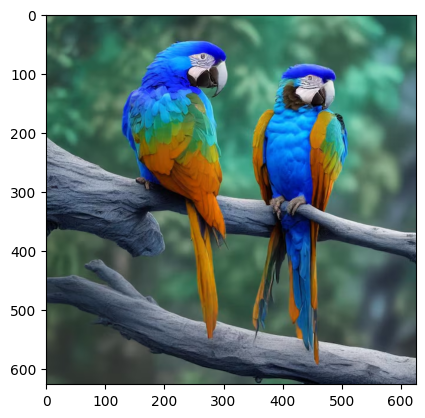

In [6]:
plt.imshow(img)

Now while reading an image using openCV, it shows image in weird bluish tint. This is because OpenCV and matplotlib expects different orders of RGB

MATPLOTLIB --> RGB - Red Green Blue

OPENCV --> BGR - Blue Green Red

So we need to transform from BGR to RGB

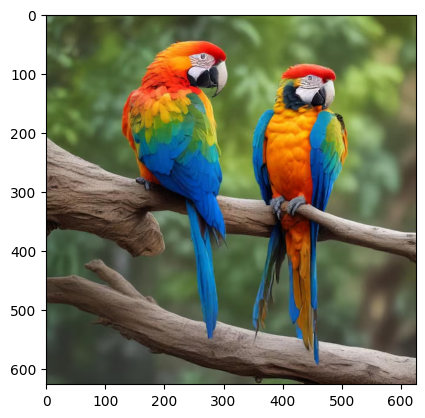

In [7]:
fix_img = cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
plt.imshow(fix_img)

In [8]:
#for gray scale image

img_gray = cv2.imread(pic,cv2.IMREAD_GRAYSCALE) #fresh read of the image and convert to gray scale
img_gray.shape

(626, 626)

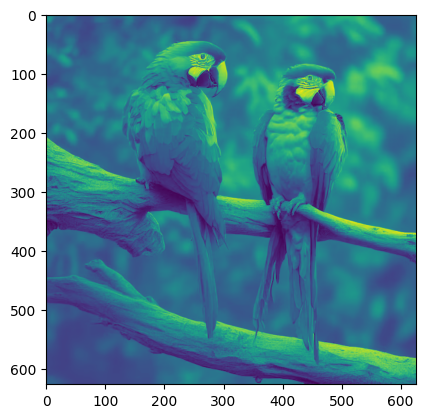

In [9]:
plt.imshow(img_gray)

So we need to again transform it to look like gray scale using cmap

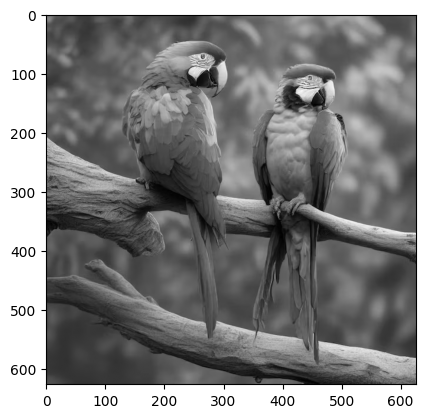

In [10]:
plt.imshow(img_gray,cmap='gray')

##### Resizing Images

In [11]:
fix_img.shape

(626, 626, 3)

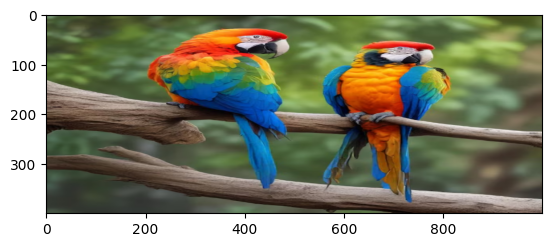

In [12]:
new_img = cv2.resize(fix_img,(1000,400)) #width =1000, height = 400
plt.imshow(new_img)

In [13]:
new_img.shape

(400, 1000, 3)

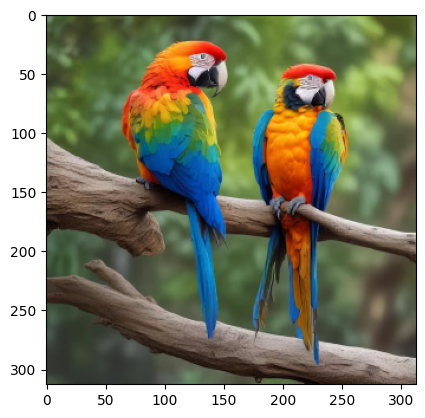

In [14]:
# resize by ratio

w_ratio = 0.5
h_ratio = 0.5
#reduce image by 50%

new_img = cv2.resize(fix_img,(0,0),fix_img,w_ratio,h_ratio) #(0,0 location from where you want to resize)
plt.imshow(new_img)

In [15]:
new_img.shape

(313, 313, 3)

##### Flip Images

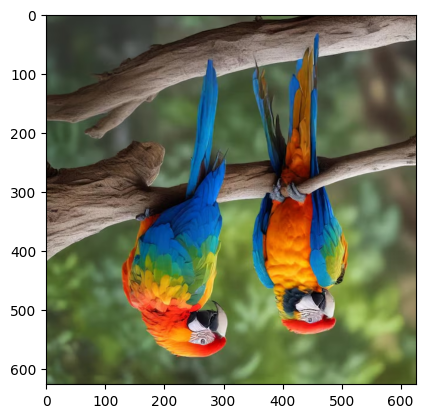

In [16]:
flip_img = cv2.flip(fix_img,0)
plt.imshow(flip_img) #horizontal

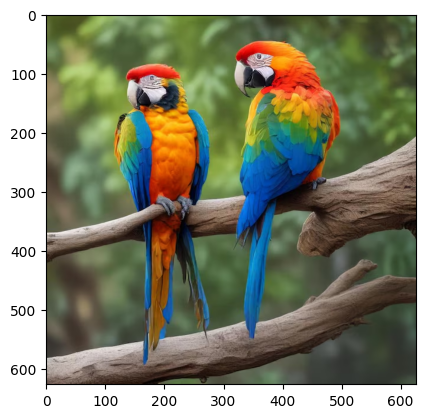

In [17]:
flip_img1 = cv2.flip(fix_img,1)
plt.imshow(flip_img1) #vertical

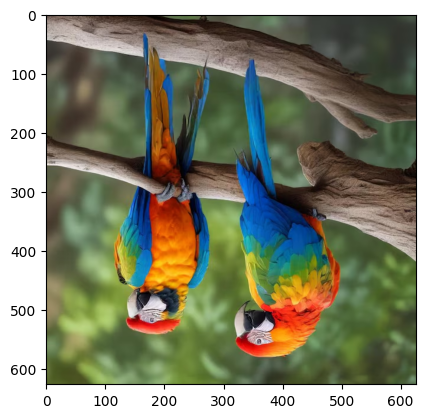

In [18]:
flip_img2 = cv2.flip(fix_img,-1)
plt.imshow(flip_img2) #vertical and horizontal both

##### Save an image file

In [19]:
type(fix_img)

numpy.ndarray

In [20]:
cv2.imwrite('image/2parrots_fixed_image.jpg',fix_img)

True

##### Resize canvas area

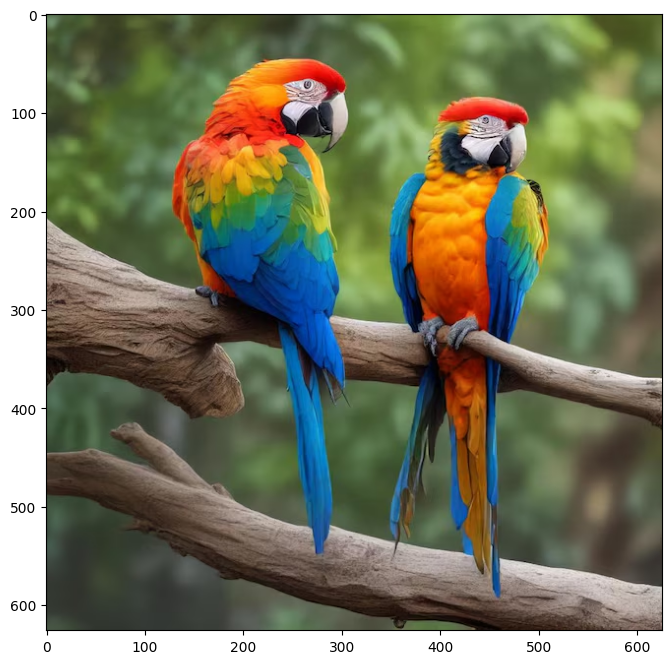

In [21]:
fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111)
ax.imshow(fix_img)